# Codveda Level 3 Project: Customer Churn Prediction

## Importing libraries and load the dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.impute import SimpleImputer

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    RocCurveDisplay,
    classification_report,
    confusion_matrix
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier




In [4]:
# Loading dataset
DATA_PATH = Path("datasets\churn-bigml-80.csv")

if not DATA_PATH.exists():
    raise FileNotFoundError(
        f"Dataset not found at {DATA_PATH.resolve()}. "
        "Make sure churn-bigml-80.csv is in the datasets folder, "
        "in the same directory as this notebook."
    )

df = pd.read_csv(DATA_PATH)
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## Initial Data Inspecting and EDA

In [3]:
df.sample(10)

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
2550,NY,122,415,No,No,0,141.4,128,24.04,146.4,70,12.44,123.0,75,5.54,8.1,4,2.19,0,False
838,NM,174,415,No,No,0,239.2,72,40.66,188.5,124,16.02,105.6,116,4.75,8.8,3,2.38,1,False
905,AL,16,408,No,No,0,209.5,89,35.62,172.8,85,14.69,94.1,102,4.23,8.8,4,2.38,1,False
21,NE,174,415,No,No,0,124.3,76,21.13,277.1,112,23.55,250.7,115,11.28,15.5,5,4.19,3,False
1548,TX,52,415,No,No,0,155.0,110,26.35,133.4,104,11.34,176.1,84,7.92,7.0,4,1.89,4,True
2145,RI,103,510,Yes,No,0,255.9,128,43.50,140.9,92,11.98,308.9,130,13.90,12.1,2,3.27,1,True
797,OR,48,415,No,No,0,190.4,92,32.37,317.5,85,26.99,133.4,113,6.00,8.3,4,2.24,2,False
2451,SD,119,510,No,No,0,94.2,108,16.01,264.1,100,22.45,203.7,79,9.17,7.3,3,1.97,1,False
2259,MS,38,415,No,No,0,117.3,114,19.94,208.7,105,17.74,203.4,98,9.15,14.4,2,3.89,2,False
1551,MS,107,510,No,Yes,30,198.9,87,33.81,207.0,90,17.60,159.8,76,7.19,12.6,4,3.40,3,False


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [5]:
# Detecting null values

df.isna().sum()

State                     0
Account length            0
Area code                 0
International plan        0
Voice mail plan           0
Number vmail messages     0
Total day minutes         0
Total day calls           0
Total day charge          0
Total eve minutes         0
Total eve calls           0
Total eve charge          0
Total night minutes       0
Total night calls         0
Total night charge        0
Total intl minutes        0
Total intl calls          0
Total intl charge         0
Customer service calls    0
Churn                     0
dtype: int64

In [6]:
# Checking duplicates

df.duplicated().sum()

np.int64(0)

Identifying Feature Types

In [7]:
# Seperate Features and Target first
X = df.drop("Churn", axis=1)
y = df["Churn"]

# Categories vs numerics

categorical_features = X.select_dtypes(include=["object"]).columns

numerical_features = X.select_dtypes(exclude=["object"]).columns

print("Categorical Columns:")
print(categorical_features)
print("-----------------------")
print("Numerical Columns:")
print(numerical_features)
print("-----------------------")

Categorical Columns:
Index(['State', 'International plan', 'Voice mail plan'], dtype='object')
-----------------------
Numerical Columns:
Index(['Account length', 'Area code', 'Number vmail messages',
       'Total day minutes', 'Total day calls', 'Total day charge',
       'Total eve minutes', 'Total eve calls', 'Total eve charge',
       'Total night minutes', 'Total night calls', 'Total night charge',
       'Total intl minutes', 'Total intl calls', 'Total intl charge',
       'Customer service calls'],
      dtype='object')
-----------------------


## ML Models: Logistic Regression, Decision Tree, Random Forest

### Preprocessing pipeline: For future reusable

In [8]:
# Numerical pipeline
numeric_transformer = Pipeline(
    [("imputer", SimpleImputer(strategy= "mean")),
     ("scaler", StandardScaler())]
)

# Categorical pipeline
categorical_transformer = Pipeline(
    [("imputer", SimpleImputer(strategy="most_frequent")),
     ("encoder", OneHotEncoder(handle_unknown="ignore"))]
)

# Combine
preprocessor = ColumnTransformer(
    [("num", numeric_transformer, numerical_features),
     ("cat", categorical_transformer, categorical_features)]
) 

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

Function for evaluating models

In [10]:
def evaluate_model(name, y_true, y_pred):

    print("="*50)
    print(name)
    print("="*50)

    print("Accuracy :", accuracy_score(y_true, y_pred))
    print("Precision:", precision_score(y_true, y_pred))
    print("Recall   :", recall_score(y_true, y_pred))
    print("F1 Score :", f1_score(y_true, y_pred))
    print()

    print(classification_report(y_true, y_pred))

### Logistic Regression Model

In [11]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)

In [12]:
log_accuracy = accuracy_score(y_test, log_pred)
log_precision = precision_score(y_test, log_pred)
log_recall = recall_score(y_test, log_pred)
log_f1 = f1_score(y_test, log_pred)
log_roc_auc = roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1])

Evaluate Logistic Regression Model

In [13]:
evaluate_model(
    "Logistic Regression",
    y_test,
    log_pred
)
print("ROC AOC :", roc_auc_score(y_test, log_model.predict_proba(X_test)[:, 1])) 

Logistic Regression
Accuracy : 0.8426966292134831
Precision: 0.425
Recall   : 0.21794871794871795
F1 Score : 0.288135593220339

              precision    recall  f1-score   support

       False       0.88      0.95      0.91       456
        True       0.42      0.22      0.29        78

    accuracy                           0.84       534
   macro avg       0.65      0.58      0.60       534
weighted avg       0.81      0.84      0.82       534

ROC AOC : 0.7435335132703553


### Decision Tree Classifier Model

In [14]:
tree_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", DecisionTreeClassifier(random_state=42))
])

tree_model.fit(X_train, y_train)
tree_pred = tree_model.predict(X_test)

In [15]:
tree_accuracy = accuracy_score(y_test, tree_pred)
tree_precision = precision_score(y_test, tree_pred)
tree_recall = recall_score(y_test, tree_pred)
tree_f1 = f1_score(y_test, tree_pred)
tree_roc_auc = roc_auc_score(y_test, tree_model.predict_proba(X_test)[:, 1])

Evaluate Decision Tree Classifier Model

In [16]:
evaluate_model(
    "Decision Tree",
    y_test,
    tree_pred
)
print("ROC AOC :", roc_auc_score(y_test, tree_model.predict_proba(X_test)[:, 1])) 

Decision Tree
Accuracy : 0.9063670411985019
Precision: 0.6794871794871795
Recall   : 0.6794871794871795
F1 Score : 0.6794871794871795

              precision    recall  f1-score   support

       False       0.95      0.95      0.95       456
        True       0.68      0.68      0.68        78

    accuracy                           0.91       534
   macro avg       0.81      0.81      0.81       534
weighted avg       0.91      0.91      0.91       534

ROC AOC : 0.8123313090418354


### Random Forest 

In [17]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(random_state=42))
])

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

In [18]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)
print("ROC AOC :", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1])) 

Random Forest
Accuracy : 0.9325842696629213
Precision: 0.9772727272727273
Recall   : 0.5512820512820513
F1 Score : 0.7049180327868853

              precision    recall  f1-score   support

       False       0.93      1.00      0.96       456
        True       0.98      0.55      0.70        78

    accuracy                           0.93       534
   macro avg       0.95      0.77      0.83       534
weighted avg       0.94      0.93      0.92       534

ROC AOC : 0.8826332658569501


Tunes Random Forest hyperparameters using GridSearchCV to liftup Recall

In [19]:
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [5, 10, 20, None],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    rf_model,
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)
best_rf_model = grid_search.best_estimator_
best_rf_pred = best_rf_model.predict(X_test)
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best Mean f1: {grid_search.best_score_:.4f}")
print("---------------------------------------------")

evaluate_model(
    "Tuned Random Forest",
    y_test,
    best_rf_pred
)
print("ROC AOC :", roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])) 

Best Parameters: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 2, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}
Best Mean f1: 0.8111
---------------------------------------------
Tuned Random Forest
Accuracy : 0.9325842696629213
Precision: 0.7916666666666666
Recall   : 0.7307692307692307
F1 Score : 0.76

              precision    recall  f1-score   support

       False       0.95      0.97      0.96       456
        True       0.79      0.73      0.76        78

    accuracy                           0.93       534
   macro avg       0.87      0.85      0.86       534
weighted avg       0.93      0.93      0.93       534

ROC AOC : 0.877642825011246


In [20]:
rf_accuracy = accuracy_score(y_test, best_rf_pred)
rf_precision = precision_score(y_test, best_rf_pred)
rf_recall = recall_score(y_test, best_rf_pred)
rf_f1 = f1_score(y_test, best_rf_pred)
rf_roc_auc = roc_auc_score(y_test, best_rf_model.predict_proba(X_test)[:, 1])

Tuned Random Forest Feature Importances

In [21]:
feature_names = best_rf_model.named_steps["preprocessor"].get_feature_names_out()
rf = best_rf_model.named_steps["classifier"]

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance.head(10))


                        Feature  Importance
15  num__Customer service calls    0.153450
3        num__Total day minutes    0.134772
5         num__Total day charge    0.133656
67   cat__International plan_No    0.066040
68  cat__International plan_Yes    0.064919
8         num__Total eve charge    0.041181
6        num__Total eve minutes    0.040204
14       num__Total intl charge    0.038246
12      num__Total intl minutes    0.032969
13        num__Total intl calls    0.032417


Plot top 10 features

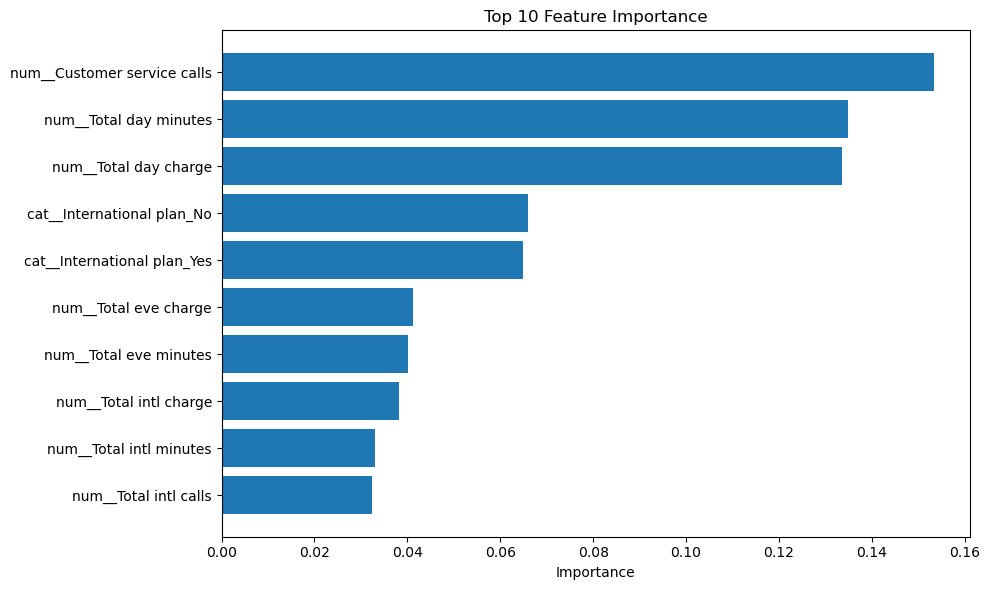

In [22]:
plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Top 10 Feature Importance")

plt.tight_layout()
plt.show()

Confusion Matrix

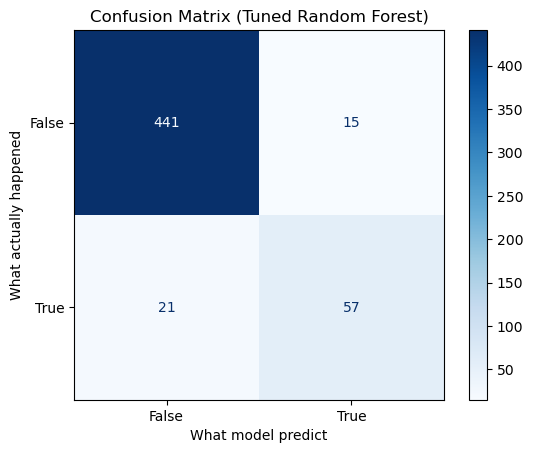

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_estimator(
    best_rf_model,
    X_test,
    y_test,
    cmap="Blues"
)
plt.title("Confusion Matrix (Tuned Random Forest)")
plt.xlabel("What model predict")
plt.ylabel("What actually happened")
plt.show()

ROC Curve

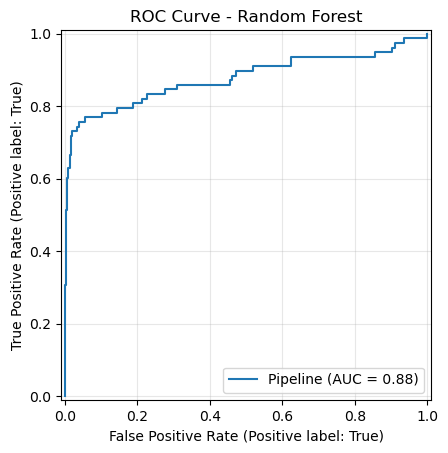

In [24]:
RocCurveDisplay.from_estimator(
    best_rf_model,
    X_test,
    y_test
)

plt.title("ROC Curve - Random Forest")
plt.grid(alpha=0.3)
plt.show()

### Models Comparison and Saving the Best Model

In [25]:
result_table = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1 Score", "ROC AUC"],
    "Logistic Regression": [log_accuracy, log_precision, log_recall, log_f1, log_roc_auc],
    "Decision Tree": [tree_accuracy, tree_precision, tree_recall, tree_f1, tree_roc_auc],
    "Random Forest": [rf_accuracy, rf_precision, rf_recall, rf_f1, rf_roc_auc]
})

result_table

,Metric,Logistic Regression,Decision Tree,Random Forest
0,Accuracy,0.842697,0.906367,0.932584
1,Precision,0.425000,0.679487,0.791667
2,Recall,0.217949,0.679487,0.730769
3,F1 Score,0.288136,0.679487,0.760000
4,ROC AUC,0.743534,0.812331,0.877643


The Best Model is Tuned Random Forest.
Saving the Best Model.

In [26]:
import joblib

joblib.dump(best_rf_model, "customer_churn_prediction_random_forest_model.pkl")

['customer_churn_prediction_random_forest_model.pkl']